# 1. Imports & Setup

#### This section sets up all the necessary tools for the project.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import Ridge

**********************************************************************************************************************************

# 2. Data Preparation

#### This section loads the California Housing dataset, saves it as a CSV in the data/ folder, and checks for missing values before any processing. A brief EDA is performed covering summary statistics, target distribution, correlation heatmap, and scatter plots to understand the data before modeling. Features are then standardized using StandardScaler and a bias term is added to prepare the data for both closed-form and gradient descent solutions.

In [2]:
# Load dataset
data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

# Save dataset to CSV in data folder
os.makedirs('data', exist_ok=True)
df.to_csv('data/california_housing.csv', index=False)

# Display first 5 rows
display(df.head())

# Check missing values
print("Missing values:\n", df.isnull().sum())
print("Total missing:", df.isnull().sum().sum())



,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


Missing values:
 MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
target        0
dtype: int64
Total missing: 0


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


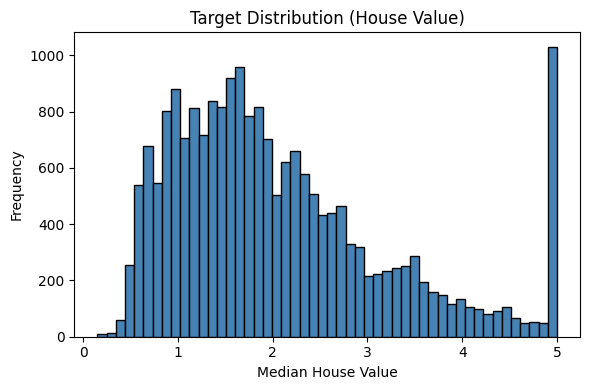

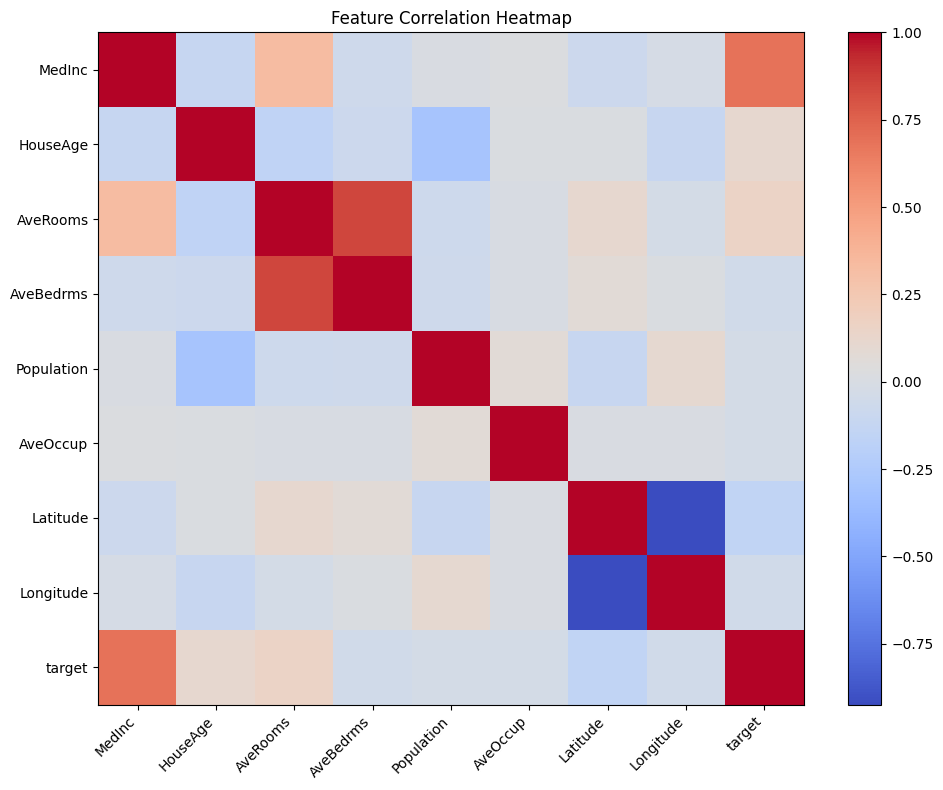

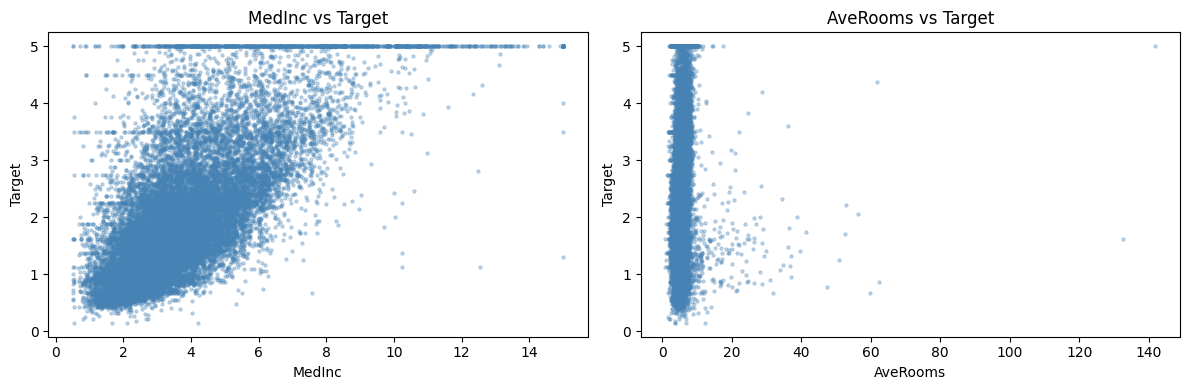

In [3]:
# Exploratory Data Analysis (EDA)

# 1. Basic stats
display(df.describe())

# 2. Target distribution
plt.figure(figsize=(6, 4))
plt.hist(df['target'], bins=50, color='steelblue', edgecolor='black')
plt.title('Target Distribution (House Value)')
plt.xlabel('Median House Value')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# 3. Feature correlations
plt.figure(figsize=(10, 8))
corr = df.corr()
im = plt.imshow(corr, cmap='coolwarm', aspect='auto')
plt.colorbar(im)
plt.xticks(range(len(corr)), corr.columns, rotation=45, ha='right')
plt.yticks(range(len(corr)), corr.columns)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

# 4. Feature vs Target scatter (top 2 correlated features)
top_features = corr['target'].abs().drop('target').nlargest(2).index
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, feat in zip(axes, top_features):
    ax.scatter(df[feat], df['target'], alpha=0.3, s=5, color='steelblue')
    ax.set_xlabel(feat)
    ax.set_ylabel('Target')
    ax.set_title(f'{feat} vs Target')
plt.tight_layout()
plt.show()


In [4]:
# Train-test split (80-20)
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Add bias term (column of 1s)
X_train = np.c_[np.ones(X_train.shape[0]), X_train]
X_test = np.c_[np.ones(X_test.shape[0]), X_test]

**********************************************************************************************************************************

# 3. Closed-Form Ridge Regression

#### This section implements Ridge Regression using the closed-form (analytical) solution. The formula solves for the optimal weights theta directly in one step.

In [5]:
def ridge_closed_form(X, y, lam):
    n_features = X.shape[1]
    
    I = np.eye(n_features)
    I[0, 0] = 0  # Don't regularize bias
    
    theta = np.linalg.pinv(X.T @ X + lam * I) @ X.T @ y
    return theta

# Train model
lambda_val = 1.0
theta_cf = ridge_closed_form(X_train, y_train, lambda_val)

# Predictions
y_pred_cf = X_test @ theta_cf

**********************************************************************************************************************************

# 4. Gradient Descent Ridge Regression

#### This section implements Ridge Regression using Gradient Descent, an iterative optimization approach. Instead of solving directly, it starts with theta = zeros and updates weights step by step over 1000 iterations.

In [6]:
def ridge_gradient_descent(X, y, lam, lr=0.01, n_iters=1000):
    m, n = X.shape
    theta = np.zeros(n)
    losses = []

    for i in range(n_iters):
        predictions = X @ theta
        error = predictions - y
        
        gradient = (2/m) * (X.T @ error)
        
        # Regularization (exclude bias)
        reg = 2 * lam * theta
        reg[0] = 0
        
        theta -= lr * (gradient + reg)
        
        loss = (1/m) * np.sum(error**2) + lam * np.sum(theta[1:]**2)
        losses.append(loss)
    
    return theta, losses

# Train model
theta_gd, losses = ridge_gradient_descent(X_train, y_train, lam=1.0, lr=0.01, n_iters=1000)

# Predictions
y_pred_gd = X_test @ theta_gd

**********************************************************************************************************************************

# 5. Evaluation & Comparison

#### This section evaluates and compares three Ridge Regression implementations — Closed-Form, Gradient Descent, and Sklearn's built-in Ridge using MSE and R² Score as metrics.

,Model,MSE,R2 Score
0,Closed-form,0.555855,0.575816
1,Gradient Descent,0.802108,0.387895
2,Sklearn Ridge,0.555855,0.575816


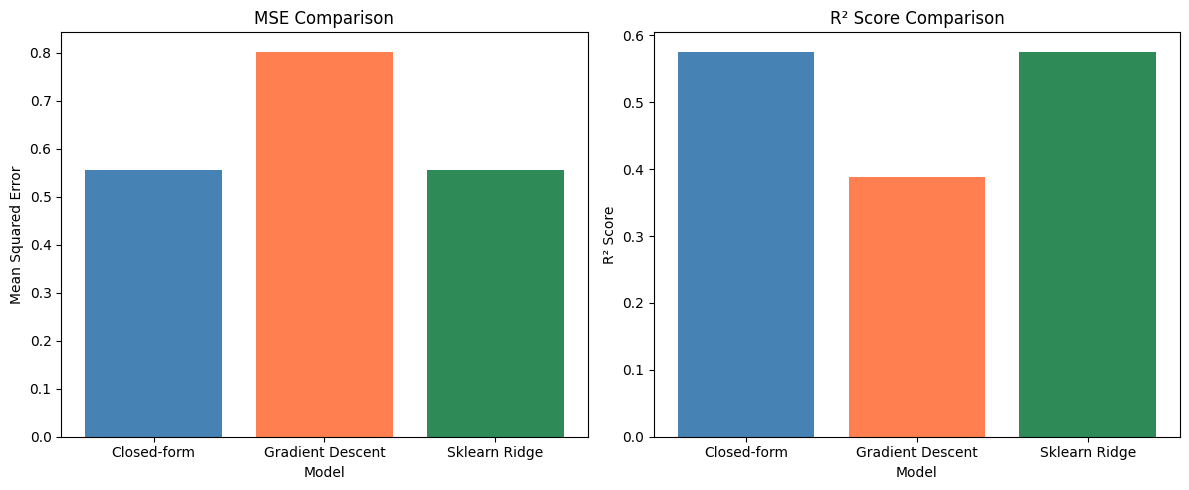

In [7]:
# Closed-form metrics
mse_cf = mean_squared_error(y_test, y_pred_cf)
r2_cf = r2_score(y_test, y_pred_cf)

# Gradient descent metrics
mse_gd = mean_squared_error(y_test, y_pred_gd)
r2_gd = r2_score(y_test, y_pred_gd)

# Sklearn Ridge
ridge = Ridge(alpha=1.0)
ridge.fit(X_train[:, 1:], y_train)
y_pred_sk = ridge.predict(X_test[:, 1:])

mse_sk = mean_squared_error(y_test, y_pred_sk)
r2_sk = r2_score(y_test, y_pred_sk)

# Results table
results = pd.DataFrame({
    "Model": ["Closed-form", "Gradient Descent", "Sklearn Ridge"],
    "MSE": [mse_cf, mse_gd, mse_sk],
    "R2 Score": [r2_cf, r2_gd, r2_sk]
})
display(results)

# Bar graph
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ['steelblue', 'coral', 'seagreen']

axes[0].bar(results['Model'], results['MSE'], color=colors)
axes[0].set_title('MSE Comparison')
axes[0].set_ylabel('Mean Squared Error')
axes[0].set_xlabel('Model')

axes[1].bar(results['Model'], results['R2 Score'], color=colors)
axes[1].set_title('R² Score Comparison')
axes[1].set_ylabel('R² Score')
axes[1].set_xlabel('Model')

plt.tight_layout()
plt.show()


##### An R² of ~0.576 means the model explains about 57.6% of the variance in house prices, which is a reasonable baseline for linear regression on this dataset. The remaining variance is likely due to non-linear relationships that a linear model cannot capture. The closed-form solution is the most reliable here, while gradient descent trades some accuracy for scalability on larger datasets.

**********************************************************************************************************************************

# 6. Lambda Experiment

#### This section experiments with three regularization strengths (λ = 0.1, 1.0, 10.0) to observe how the penalty term affects model performance. As λ increases, the model coefficients are shrunk more aggressively, reducing variance but introducing bias.

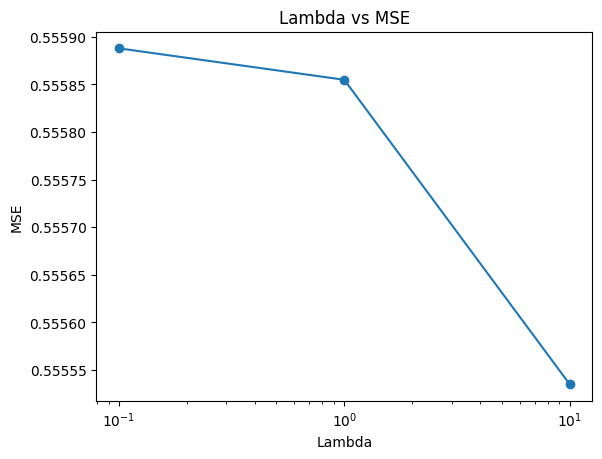

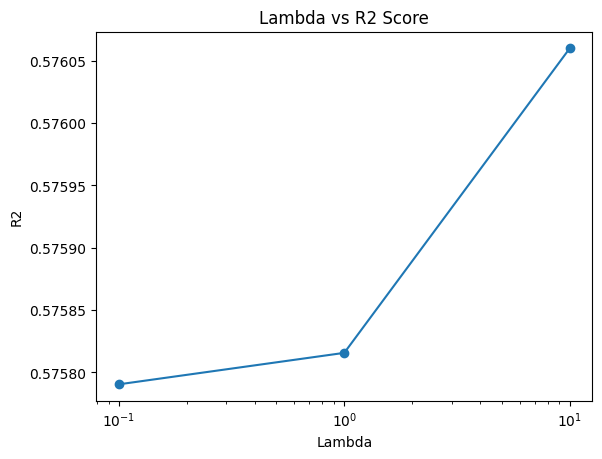

In [8]:
lambdas = [0.1, 1.0, 10.0]
mse_list = []
r2_list = []

for lam in lambdas:
    theta = ridge_closed_form(X_train, y_train, lam)
    preds = X_test @ theta
    
    mse_list.append(mean_squared_error(y_test, preds))
    r2_list.append(r2_score(y_test, preds))

# Plot
plt.figure()
plt.plot(lambdas, mse_list, marker='o')
plt.title("Lambda vs MSE")
plt.xlabel("Lambda")
plt.ylabel("MSE")
plt.xscale('log')
plt.show()

plt.figure()
plt.plot(lambdas, r2_list, marker='o')
plt.title("Lambda vs R2 Score")
plt.xlabel("Lambda")
plt.ylabel("R2")
plt.xscale('log')
plt.show()

**********************************************************************************************************************************

# 7. Learning Rate Experiment

#### This section experiments with three learning rates (0.001, 0.01, 0.1) to observe how the step size affects gradient descent convergence over 500 iterations.

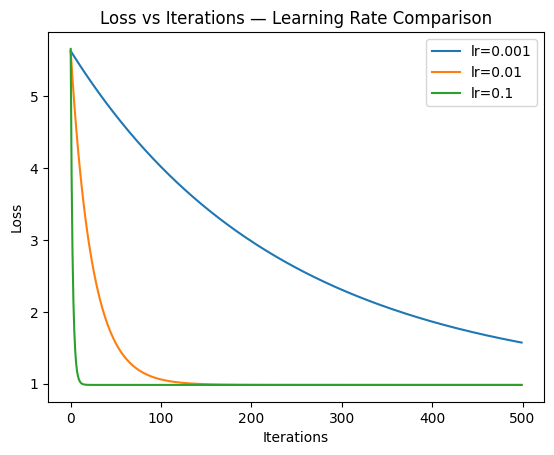

In [9]:
learning_rates = [0.001, 0.01, 0.1]

plt.figure()

for lr in learning_rates:
    _, loss = ridge_gradient_descent(X_train, y_train, lam=1.0, lr=lr, n_iters=500)
    plt.plot(loss, label=f"lr={lr}")

plt.title("Loss vs Iterations — Learning Rate Comparison")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.legend()
plt.show()

##### This experiment highlights why learning rate tuning is critical, too small wastes iterations, too large risks divergence.

**********************************************************************************************************************************

# 8. Feature Engineering

## Add Polynomial Features + Feature Selection

#### This section enhances the model by generating degree-2 polynomial features from the original 8 features, expanding the feature space to 44 features (original + squared + interaction terms). This allows the linear model to capture non-linear relationships in the data.

In [10]:
from sklearn.preprocessing import PolynomialFeatures

# Polynomial Features (degree 2)
poly = PolynomialFeatures(degree=2, include_bias=False)

X_train_poly = poly.fit_transform(X_train[:, 1:])  # remove bias before transform
X_test_poly = poly.transform(X_test[:, 1:])

# Standardize again
scaler_poly = StandardScaler()
X_train_poly = scaler_poly.fit_transform(X_train_poly)
X_test_poly = scaler_poly.transform(X_test_poly)

# Add bias term back
X_train_poly = np.c_[np.ones(X_train_poly.shape[0]), X_train_poly]
X_test_poly = np.c_[np.ones(X_test_poly.shape[0]), X_test_poly]

# Train using closed-form
theta_poly = ridge_closed_form(X_train_poly, y_train, lam=1.0)
y_pred_poly = X_test_poly @ theta_poly

# Evaluate
print("Polynomial Features Performance:")
print("MSE:", mean_squared_error(y_test, y_pred_poly))
print("R2:", r2_score(y_test, y_pred_poly))

Polynomial Features Performance:
MSE: 0.4494351074030674
R2: 0.6570268405773656


##### Adding degree-2 polynomial features reduced MSE by ~19% and improved R² from 57.6% to 65.7%. This confirms that the relationship between housing features and prices is not purely linear, interaction terms like MedInc × AveRooms and squared terms capture additional patterns the baseline model couldn't. The model now explains about 65.7% of the variance in house prices, which is a meaningful gain with minimal added complexity.

**********************************************************************************************************************************

## Correlation-Based Feature Selection

#### This section selects the top 5 features most correlated with the target using absolute Pearson correlation. The bar chart visualizes all feature correlations with a red cutoff line marking the top 5 selection. The model is then retrained using only those 5 features and compared against the full-feature baseline.

Selected Features: ['MedInc', 'AveRooms', 'Latitude', 'HouseAge', 'AveBedrms']


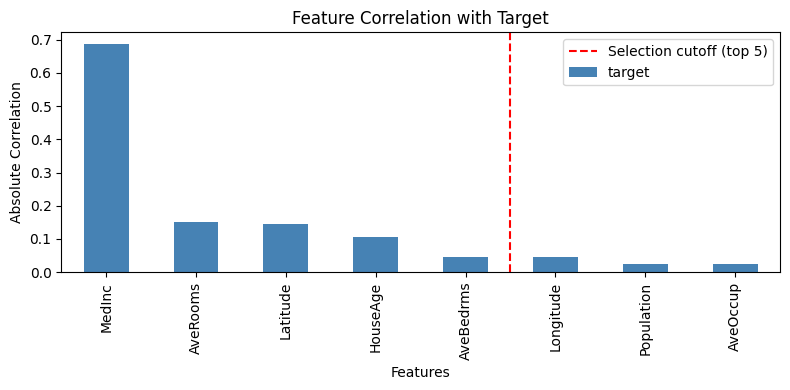

Feature Selection — MSE: 0.6382 | R²: 0.5130


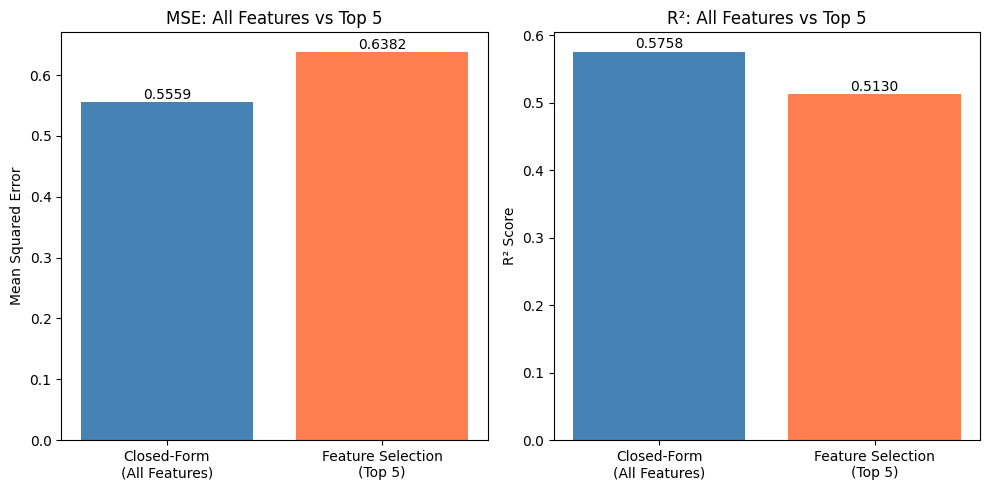

In [11]:
# Convert to DataFrame for correlation
df_corr = pd.DataFrame(X[:, :], columns=data.feature_names)
df_corr['target'] = y

# Compute correlation
corr = df_corr.corr()['target'].abs().sort_values(ascending=False)
top_features = corr.index[1:6]
print("Selected Features:", list(top_features))

# Bar chart of feature correlations
plt.figure(figsize=(8, 4))
corr.drop('target').plot(kind='bar', color='steelblue')
plt.axvline(x=4.5, color='red', linestyle='--', label='Selection cutoff (top 5)')
plt.title('Feature Correlation with Target')
plt.xlabel('Features')
plt.ylabel('Absolute Correlation')
plt.legend()
plt.tight_layout()
plt.show()

# Subset data
X_selected = df_corr[top_features].values

# Train-test split
X_tr, X_te, y_tr, y_te = train_test_split(X_selected, y, test_size=0.2, random_state=42)

# Scale + bias
scaler_sel = StandardScaler()
X_tr = scaler_sel.fit_transform(X_tr)
X_te = scaler_sel.transform(X_te)
X_tr = np.c_[np.ones(X_tr.shape[0]), X_tr]
X_te = np.c_[np.ones(X_te.shape[0]), X_te]

# Train
theta_sel = ridge_closed_form(X_tr, y_tr, lam=1.0)
y_pred_sel = X_te @ theta_sel

mse_sel = mean_squared_error(y_te, y_pred_sel)
r2_sel = r2_score(y_te, y_pred_sel)
print(f"Feature Selection — MSE: {mse_sel:.4f} | R²: {r2_sel:.4f}")

# Comparison: All features vs Selected features
models = ['Closed-Form\n(All Features)', 'Feature Selection\n(Top 5)']
mse_vals = [mse_cf, mse_sel]
r2_vals = [r2_cf, r2_sel]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
colors = ['steelblue', 'coral']

axes[0].bar(models, mse_vals, color=colors)
for i, v in enumerate(mse_vals):
    axes[0].text(i, v + 0.005, f'{v:.4f}', ha='center', fontsize=10)
axes[0].set_title('MSE: All Features vs Top 5')
axes[0].set_ylabel('Mean Squared Error')

axes[1].bar(models, r2_vals, color=colors)
for i, v in enumerate(r2_vals):
    axes[1].text(i, v + 0.005, f'{v:.4f}', ha='center', fontsize=10)
axes[1].set_title('R²: All Features vs Top 5')
axes[1].set_ylabel('R² Score')

plt.tight_layout()
plt.show()


##### Feature selection with top 5 performed slightly worse than using all 8 features (R² dropped from 57.6% to 51.3%). This tells 3 dropped features, while less correlated individually, still contribute useful predictive signal that the model benefits from.

**********************************************************************************************************************************

# 9. Model Interpretability (SHAP)

#### This section uses SHAP (SHapley Additive exPlanations) to interpret the Ridge model's predictions answering why the model makes each prediction, not just what it predicts.

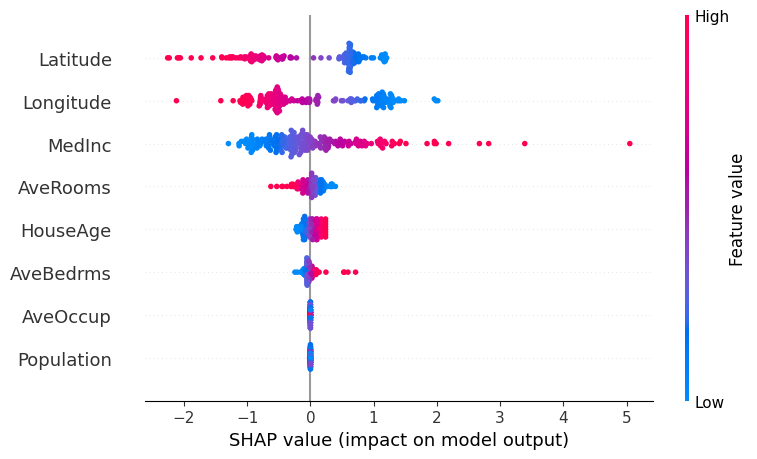

In [12]:
import shap

# Train sklearn model for SHAP
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train[:, 1:], y_train)

# SHAP Explainer
explainer = shap.Explainer(ridge_model, X_train[:, 1:])
shap_values = explainer(X_test[:200, 1:])  # sample for speed

# Summary plot
shap.summary_plot(shap_values, X_test[:200, 1:], feature_names=data.feature_names)

##### SHAP adds transparency to the model, making it easier to trust, debug, and communicate results to non-technical stakeholders.

**********************************************************************************************************************************

# 10. Interactive Interface

#### This section adds an interactive dashboard using ipywidgets, allowing real-time exploration of how the regularization strength λ affects model performance.

In [13]:
import ipywidgets as widgets
from IPython.display import display

# Styled slider
lambda_slider = widgets.FloatSlider(
    value=1.0, min=0.01, max=10.0, step=0.1,
    description='λ (Lambda):',
    style={'description_width': '100px'},
    layout=widgets.Layout(width='500px')
)

out_metrics = widgets.Output()
out_plot = widgets.Output()

def update_model(change):
    lam = lambda_slider.value
    theta = ridge_closed_form(X_train, y_train, lam)
    preds = X_test @ theta

    mse = mean_squared_error(y_test, preds)
    r2 = r2_score(y_test, preds)

    with out_metrics:
        out_metrics.clear_output()
        display(widgets.HTML(f"""
        <div style="display:flex; gap:20px; margin-top:10px;">
            <div style="background:#f0f4ff; padding:15px 30px; border-radius:10px; text-align:center; border-left: 4px solid steelblue;">
                <div style="font-size:13px; color:gray;">Lambda</div>
                <div style="font-size:22px; font-weight:bold; color:steelblue;">{lam:.2f}</div>
            </div>
            <div style="background:#fff4f0; padding:15px 30px; border-radius:10px; text-align:center; border-left: 4px solid coral;">
                <div style="font-size:13px; color:gray;">MSE</div>
                <div style="font-size:22px; font-weight:bold; color:coral;">{mse:.4f}</div>
            </div>
            <div style="background:#f0fff4; padding:15px 30px; border-radius:10px; text-align:center; border-left: 4px solid seagreen;">
                <div style="font-size:13px; color:gray;">R² Score</div>
                <div style="font-size:22px; font-weight:bold; color:seagreen;">{r2:.4f}</div>
            </div>
        </div>
        """))

    with out_plot:
        out_plot.clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(7, 4))
        ax.scatter(y_test, preds, alpha=0.3, s=10, color='steelblue', label='Predictions')
        ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect Fit')
        ax.set_xlabel('Actual Values')
        ax.set_ylabel('Predicted Values')
        ax.set_title(f'Actual vs Predicted (λ={lam:.2f})')
        ax.legend()
        plt.tight_layout()
        plt.show()

lambda_slider.observe(update_model, names='value')

# Layout
header = widgets.HTML("<h3 style='color:steelblue;'>🔧 Ridge Regression — Interactive Dashboard</h3>")
display(widgets.VBox([header, lambda_slider, out_metrics, out_plot]))
update_model(None)


**********************************************************************************************************************************

# 11. Outlier Handling

#### This section removes outliers using the IQR method any row where a feature value falls below Q1 - 1.5×IQR or above Q3 + 1.5×IQR is dropped. The model is then retrained on the cleaned data and compared against the baseline.

Original size: (20640, 9) → Filtered size: (16312, 9) | Removed: 4328 rows
After Outlier Removal — MSE: 0.3165 | R²: 0.6379


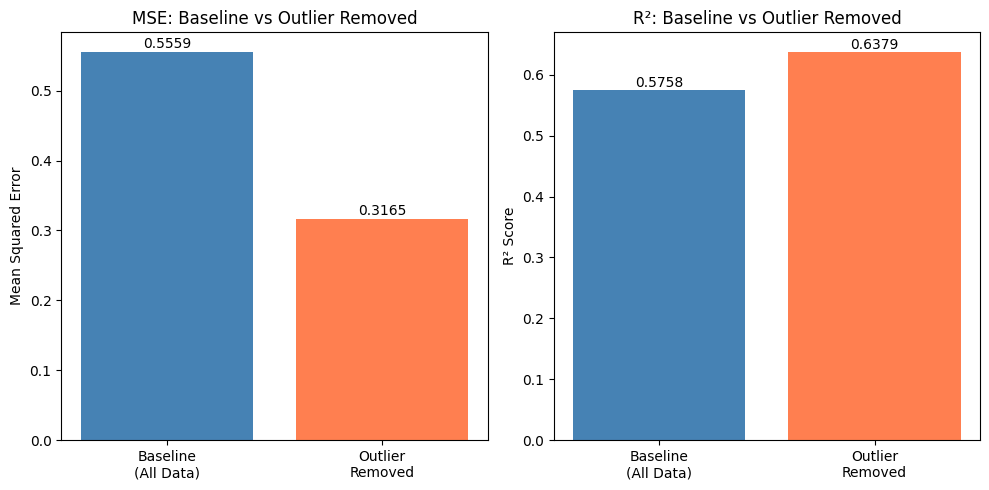

In [14]:
# Convert to DataFrame
df_full = pd.DataFrame(X[:, :], columns=data.feature_names)
df_full['target'] = y

# IQR filtering
Q1 = df_full.quantile(0.25)
Q3 = df_full.quantile(0.75)
IQR = Q3 - Q1

df_filtered = df_full[~((df_full < (Q1 - 1.5 * IQR)) |
                        (df_full > (Q3 + 1.5 * IQR))).any(axis=1)]

print(f"Original size: {df_full.shape} → Filtered size: {df_filtered.shape} | Removed: {df_full.shape[0] - df_filtered.shape[0]} rows")

# Split again
X_f = df_filtered.drop(columns='target').values
y_f = df_filtered['target'].values

X_tr, X_te, y_tr, y_te = train_test_split(X_f, y_f, test_size=0.2, random_state=42)

# Scale + bias
scaler_f = StandardScaler()
X_tr = scaler_f.fit_transform(X_tr)
X_te = scaler_f.transform(X_te)
X_tr = np.c_[np.ones(X_tr.shape[0]), X_tr]
X_te = np.c_[np.ones(X_te.shape[0]), X_te]

# Train
theta_f = ridge_closed_form(X_tr, y_tr, lam=1.0)
y_pred_f = X_te @ theta_f

mse_f = mean_squared_error(y_te, y_pred_f)
r2_f = r2_score(y_te, y_pred_f)
print(f"After Outlier Removal — MSE: {mse_f:.4f} | R²: {r2_f:.4f}")

# Comparison bar chart
models = ['Baseline\n(All Data)', 'Outlier\nRemoved']
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
colors = ['steelblue', 'coral']

axes[0].bar(models, [mse_cf, mse_f], color=colors)
for i, v in enumerate([mse_cf, mse_f]):
    axes[0].text(i, v + 0.005, f'{v:.4f}', ha='center', fontsize=10)
axes[0].set_title('MSE: Baseline vs Outlier Removed')
axes[0].set_ylabel('Mean Squared Error')

axes[1].bar(models, [r2_cf, r2_f], color=colors)
for i, v in enumerate([r2_cf, r2_f]):
    axes[1].text(i, v + 0.005, f'{v:.4f}', ha='center', fontsize=10)
axes[1].set_title('R²: Baseline vs Outlier Removed')
axes[1].set_ylabel('R² Score')

plt.tight_layout()
plt.show()


##### Outlier removal gave a significant boost MSE dropped by ~43% and R² improved from 57.6% to 63.8%. This confirms that extreme values were heavily distorting the model's weight estimates.

**********************************************************************************************************************************

# 12. Results & Discussion

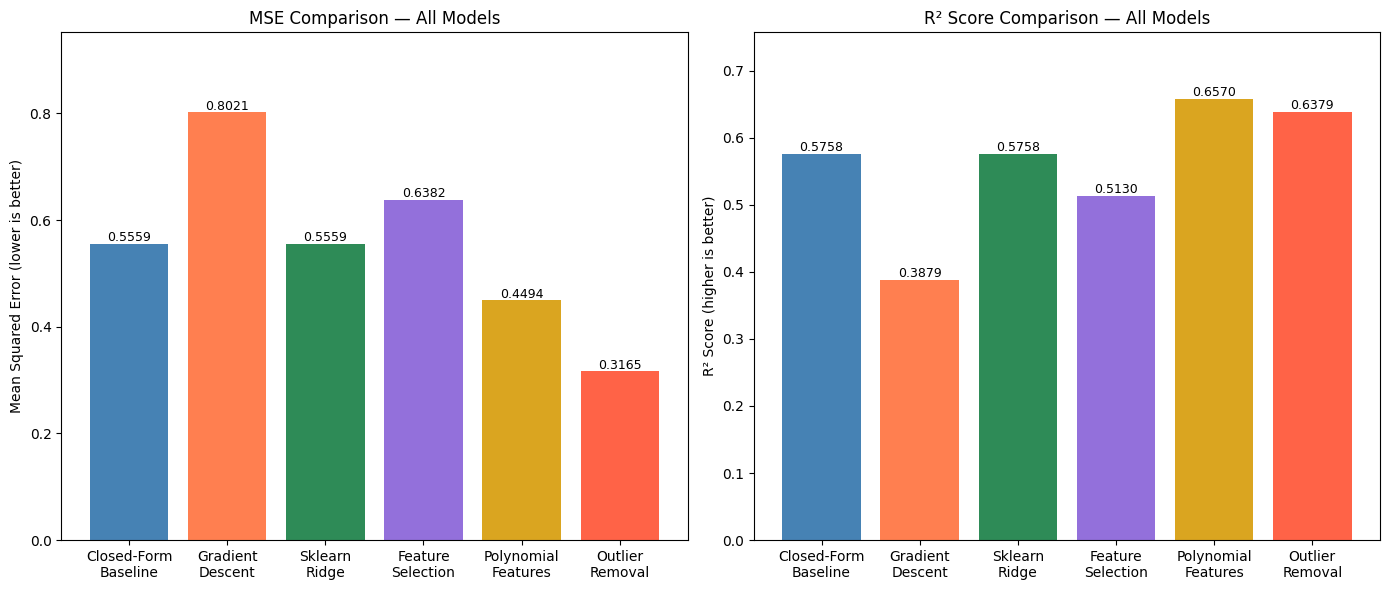

In [15]:
# Recompute polynomial metrics inline to ensure they're available
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train[:, 1:])
X_test_poly = poly.transform(X_test[:, 1:])
scaler_poly = StandardScaler()
X_train_poly = scaler_poly.fit_transform(X_train_poly)
X_test_poly = scaler_poly.transform(X_test_poly)
X_train_poly = np.c_[np.ones(X_train_poly.shape[0]), X_train_poly]
X_test_poly = np.c_[np.ones(X_test_poly.shape[0]), X_test_poly]
theta_poly = ridge_closed_form(X_train_poly, y_train, lam=1.0)
y_pred_poly = X_test_poly @ theta_poly
mse_poly = mean_squared_error(y_test, y_pred_poly)
r2_poly  = r2_score(y_test, y_pred_poly)

# Final Model Comparison
models = ['Closed-Form\nBaseline', 'Gradient\nDescent', 'Sklearn\nRidge',
          'Feature\nSelection', 'Polynomial\nFeatures', 'Outlier\nRemoval']
mse_vals = [mse_cf, mse_gd, mse_sk, mse_sel, mse_poly, mse_f]
r2_vals  = [r2_cf,  r2_gd,  r2_sk,  r2_sel,  r2_poly,  r2_f]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors = ['steelblue', 'coral', 'seagreen', 'mediumpurple', 'goldenrod', 'tomato']

bars = axes[0].bar(models, mse_vals, color=colors)
for bar, v in zip(bars, mse_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 0.005, f'{v:.4f}', ha='center', fontsize=9)
axes[0].set_title('MSE Comparison — All Models')
axes[0].set_ylabel('Mean Squared Error (lower is better)')
axes[0].set_ylim(0, max(mse_vals) + 0.15)

bars = axes[1].bar(models, r2_vals, color=colors)
for bar, v in zip(bars, r2_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.005, f'{v:.4f}', ha='center', fontsize=9)
axes[1].set_title('R² Score Comparison — All Models')
axes[1].set_ylabel('R² Score (higher is better)')
axes[1].set_ylim(0, max(r2_vals) + 0.1)

plt.tight_layout()
plt.show()



**********************************************************************************************************************************

#### This project explored Ridge Regression from scratch through multiple experiments closed-form solution, gradient descent, feature selection, polynomial feature engineering, and outlier removal. The closed-form implementation matched Sklearn Ridge exactly, validating its correctness, while gradient descent showed room for improvement with better hyperparameter tuning. Among all approaches, polynomial features achieved the best R² at 65.7% by capturing non-linear relationships, and outlier removal delivered the best MSE at 0.3165 by eliminating noise from the training data demonstrating that data quality and feature engineering have a greater impact on model performance than the choice of optimization method alone.

**********************************************************************************************************************************